# US Markets Scenario Project

Strategic stacked mean-CVaR portfolio with separate Vorobets-style EP/FFR scenario tests.

Core rules for this notebook:
- Use **exposures**, not weights.
- Use log changes / log returns inside the engine.
- Convert back to simple returns for every displayed outcome return, especially KDE plots and FFR terminal returns.
- Keep the strategic portfolio separate from scenario conditioning.
- Run each conditioning variable separately first.
- Follow the chapter-style FFR approach: state-specific mean and volatility views, EP state probability vectors, then state-dependent resampling.
- Drop oil and S&P state for now.

In [115]:
# Optional installs if needed:
# !pip install yfinance fortitudo_tech seaborn matplotlib pandas numpy cvxopt

import os
from itertools import product

import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import fortitudo.tech as ft
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#2f3437",
        "axes.edgecolor": "#d5d8dc",
        "grid.color": "#e7e9ec",
        "grid.linewidth": 0.8,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    },
)
palette = {
    "Low": "#2f6f9f",
    "Mid": "#8a8f98",
    "High": "#b4433c",
    "Normal": "#3d7f5f",
    "Crisis": "#b4433c",
    "Bull": "#2f8f6b",
    "Neutral": "#8a8f98",
    "Bear": "#b4433c",
    "30Y ZCB down / rising-yield pressure": "#b4433c",
    "30Y neutral": "#8a8f98",
    "30Y ZCB up / falling-yield support": "#2f8f6b",
}
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.random.seed(7)

## 1. Project Parameters

These are intentionally free parameters. Change these first, then rerun the notebook.

In [116]:
assets = {
    "US broad equity": "VOO",
    "Nasdaq 100": "QQQ",
    "Gold": "GLD",
    "Spain": "EWP",
    "Poland / Eastern Europe proxy": "EPOL",
    "Emerging markets ex China": "EMXC",
    "Latin America": "ILF",
}

state_tickers = {
    "VIX": "^VIX",
    "VIX 3M": "^VIX3M",
}

fred_series = {
    "US 30Y yield": "DGS30",
}

# Keep the key outside the notebook file, e.g. in the shell before launching Jupyter:
# export FRED_API_KEY="..."
fred_api_key = os.getenv("FRED_API_KEY")

# EMXC constrains the common live history to mid-2017.
start = "2017-07-18"

# Strategic optimizer parameters. Keep num_bootstraps modest while iterating.
num_bootstraps = 200
sample_size_days = 756
num_frontier_portfolios = 9
frontier_index = 4
stacking_folds = 20
alpha = 0.90
# Long-only with a 20% maximum exposure per asset.
max_exposure = 0.20

# FFR parameters.
ffr_num_paths = 10000
ffr_horizons = [21, 126]
state_half_life_fraction = 0.5

## 2. Data Helpers

In [117]:
def download_yahoo_prices(ticker_map, start):
    tickers = list(ticker_map.values())
    raw = yf.download(tickers, start=start, auto_adjust=False, progress=False)
    field = "Adj Close" if isinstance(raw.columns, pd.MultiIndex) and "Adj Close" in raw.columns.get_level_values(0) else "Close"
    prices = raw[field] if isinstance(raw.columns, pd.MultiIndex) else raw
    prices = prices.rename(columns={v: k for k, v in ticker_map.items()})
    prices = prices.sort_index().ffill().dropna(how="all")
    return prices


def load_fred_series(series_id, name, start, api_key=None):
    if api_key:
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = {
            "series_id": series_id,
            "api_key": api_key,
            "file_type": "json",
            "observation_start": start,
        }
        payload = pd.read_json(url + "?" + "&".join(f"{k}={v}" for k, v in params.items()))
        df = pd.DataFrame(payload.loc["observations", 0])
        df = df.rename(columns={"value": name})
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")[[name]]
    else:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url, parse_dates=["observation_date"])
        df = df.rename(columns={"observation_date": "date", series_id: name}).set_index("date")
        df = df.loc[start:]
    df[name] = pd.to_numeric(df[name].replace(".", np.nan), errors="coerce")
    return df.ffill().dropna()


def log_returns(prices):
    clean = prices[prices > 0].dropna(axis=0, how="any")
    pnl = np.diff(np.log(clean.values), axis=0)
    return pd.DataFrame(pnl, index=clean.index[1:], columns=clean.columns)


def log_to_simple_return(log_return):
    return np.exp(log_return) - 1


def cumulative_log_to_simple_return(log_returns):
    return np.exp(np.cumsum(log_returns, axis=1))[:, -1] - 1


def exposure_constraints(num_assets, max_exposure=1.0):
    G = np.vstack((-np.eye(num_assets), np.eye(num_assets)))
    h = np.hstack((np.zeros(num_assets), max_exposure * np.ones(num_assets)))
    A = np.ones((1, num_assets))
    b = np.ones(1)
    return G, h, A, b


def show_data_summary(prices, pnl):
    print(f"Assets found: {prices.shape[1]} / {len(assets)}")
    print(f"Price observations: {len(prices)} ({len(prices) / 252:,.2f} trading years approx.)")
    print(f"Date range: {prices.index[0].date()} -> {prices.index[-1].date()}")
    print(f"Returns: {pnl.shape[0]} days x {pnl.shape[1]} assets")
    return np.round(ft.simulation_moments(pnl), 4)

## 3. Asset Data

In [118]:
asset_prices = download_yahoo_prices(assets, start=start)
asset_pnl = log_returns(asset_prices)
show_data_summary(asset_prices, asset_pnl)

Assets found: 7 / 7
Price observations: 2223 (8.82 trading years approx.)
Date range: 2017-07-18 -> 2026-05-20
Returns: 2216 days x 7 assets


,Mean,Volatility,Skewness,Kurtosis
Ticker,,,,
Emerging markets ex China,0.0004,0.0125,-1.3326,19.6181
Poland / Eastern Europe proxy,0.0003,0.0178,-0.2641,8.0317
Spain,0.0004,0.0140,-1.2823,19.6841
Gold,0.0006,0.0103,-0.7760,11.8005
Latin America,0.0002,0.0182,-1.1747,17.1499
Nasdaq 100,0.0007,0.0147,-0.3721,10.2529
US broad equity,0.0006,0.0119,-0.6558,18.4080


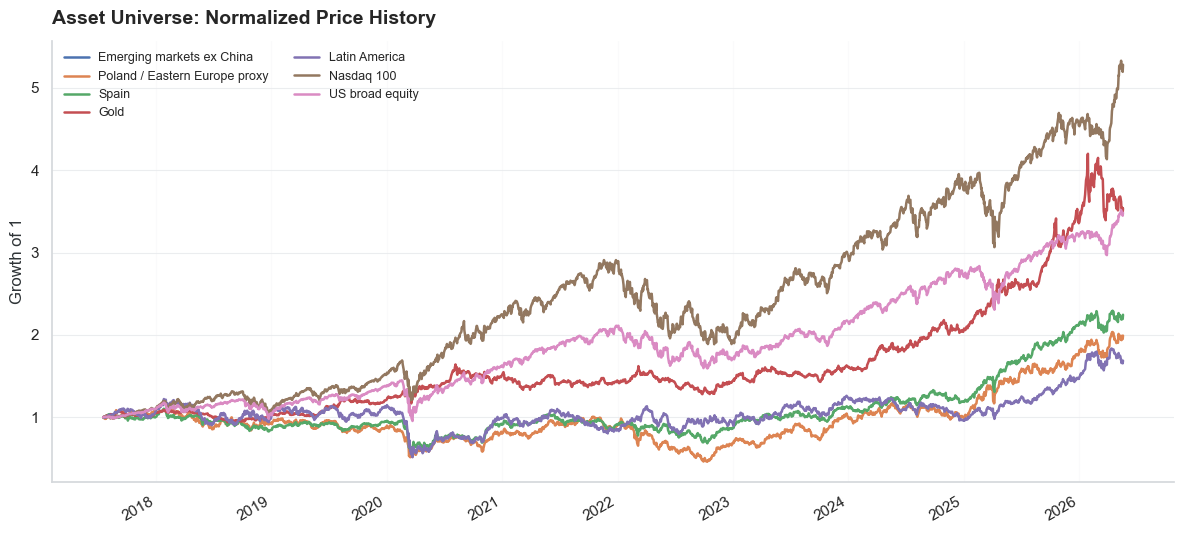

In [119]:
fig, ax = plt.subplots(figsize=(12, 5.5))
asset_prices.divide(asset_prices.iloc[0]).plot(ax=ax, linewidth=1.8)
ax.set_title("Asset Universe: Normalized Price History", loc="left", fontsize=14, pad=12)
ax.set_ylabel("Growth of 1")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.grid(axis="y", alpha=0.8)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 4. State Variables And Mosaic Check

Before EP/FFR, inspect the raw state variables. The 30Y yield FFR will use the stationary 30Y zero-coupon log change, not the raw yield level.

In [120]:
state_prices = download_yahoo_prices(state_tickers, start=start)
yield_30y = load_fred_series(fred_series["US 30Y yield"], "US 30Y yield", start=start, api_key=fred_api_key)

state_raw = state_prices.join(yield_30y, how="outer").ffill().dropna()
state_raw["VIX term"] = state_raw["VIX"] - state_raw["VIX 3M"]
state_raw["US 30Y ZCB"] = np.exp(-state_raw["US 30Y yield"] / 100 * 30)
state_raw["US 30Y ZCB log change"] = np.log(state_raw["US 30Y ZCB"]).diff()
state_raw = state_raw.dropna()

state_raw.tail()

,VIX,VIX 3M,US 30Y yield,VIX term,US 30Y ZCB,US 30Y ZCB log change
Date,,,,,,
2026-05-15,18.4300,21.3600,5.1200,-2.9300,0.2152,-0.0300
2026-05-18,17.8200,20.9200,5.1400,-3.1000,0.2140,-0.0060
2026-05-19,18.0600,21.1200,5.1800,-3.0600,0.2114,-0.0120
2026-05-20,17.4400,20.7600,5.1800,-3.3200,0.2114,0.0000
2026-05-21,17.6300,20.7600,5.1800,-3.1300,0.2114,0.0000


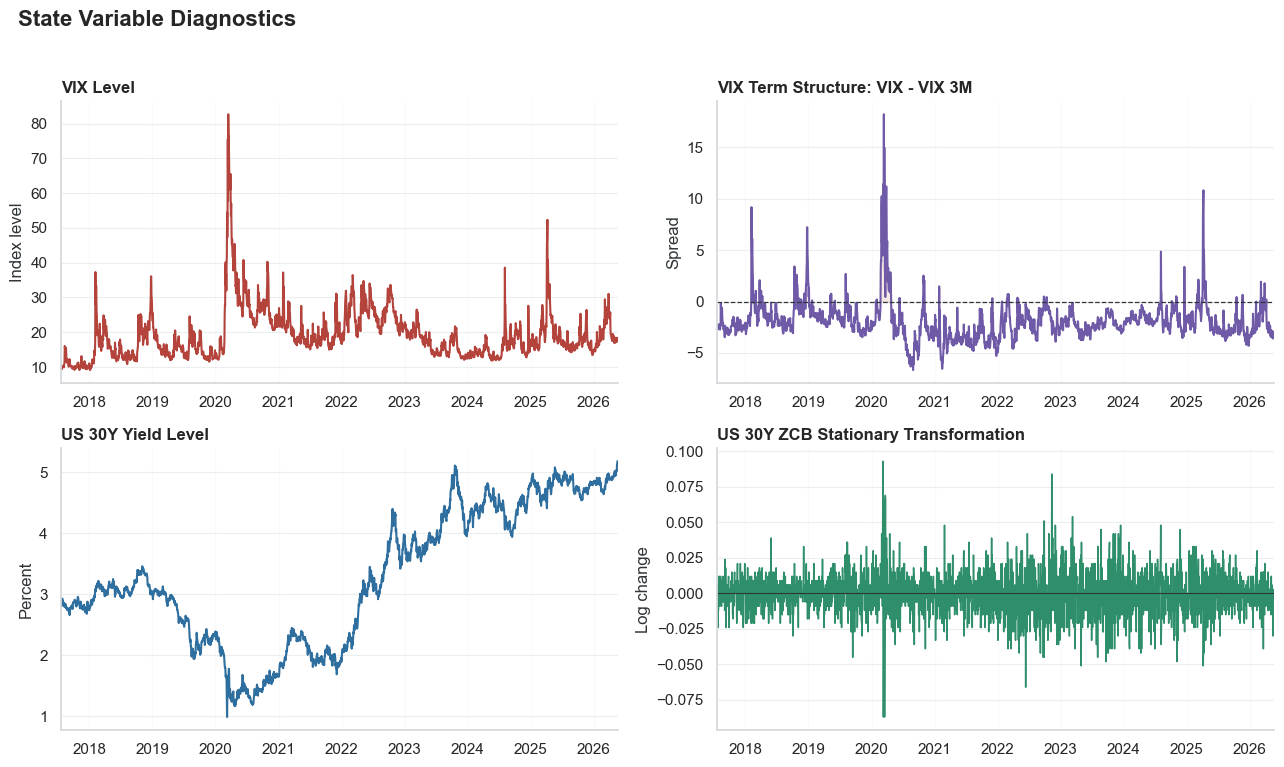

In [121]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7.5))
fig.suptitle("State Variable Diagnostics", x=0.02, y=1.02, ha="left", fontsize=16, fontweight="bold")

state_raw["VIX"].plot(ax=ax[0, 0], color="#b4433c", linewidth=1.5)
ax[0, 0].set_title("VIX Level", loc="left")
ax[0, 0].set_ylabel("Index level")

state_raw["VIX term"].plot(ax=ax[0, 1], color="#6f5aa7", linewidth=1.5)
ax[0, 1].axhline(0, color="#2f3437", linewidth=0.9, linestyle="--")
ax[0, 1].fill_between(state_raw.index, 0, state_raw["VIX term"], where=state_raw["VIX term"] > 0, color="#b4433c", alpha=0.12)
ax[0, 1].set_title("VIX Term Structure: VIX - VIX 3M", loc="left")
ax[0, 1].set_ylabel("Spread")

state_raw["US 30Y yield"].plot(ax=ax[1, 0], color="#2f6f9f", linewidth=1.5)
ax[1, 0].set_title("US 30Y Yield Level", loc="left")
ax[1, 0].set_ylabel("Percent")

state_raw["US 30Y ZCB log change"].plot(ax=ax[1, 1], color="#2f8f6b", linewidth=1.1)
ax[1, 1].axhline(0, color="#2f3437", linewidth=0.8)
ax[1, 1].set_title("US 30Y ZCB Stationary Transformation", loc="left")
ax[1, 1].set_ylabel("Log change")

for axis in ax.ravel():
    axis.set_xlabel("")
    axis.grid(axis="y", alpha=0.8)
    axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Market Case Definition Diagram

A simple client-facing view of how we define the market cases: three main sources of uncertainty this year feed into Bull, Neutral, and Bear cases, which are then evaluated on the strategic portfolio.

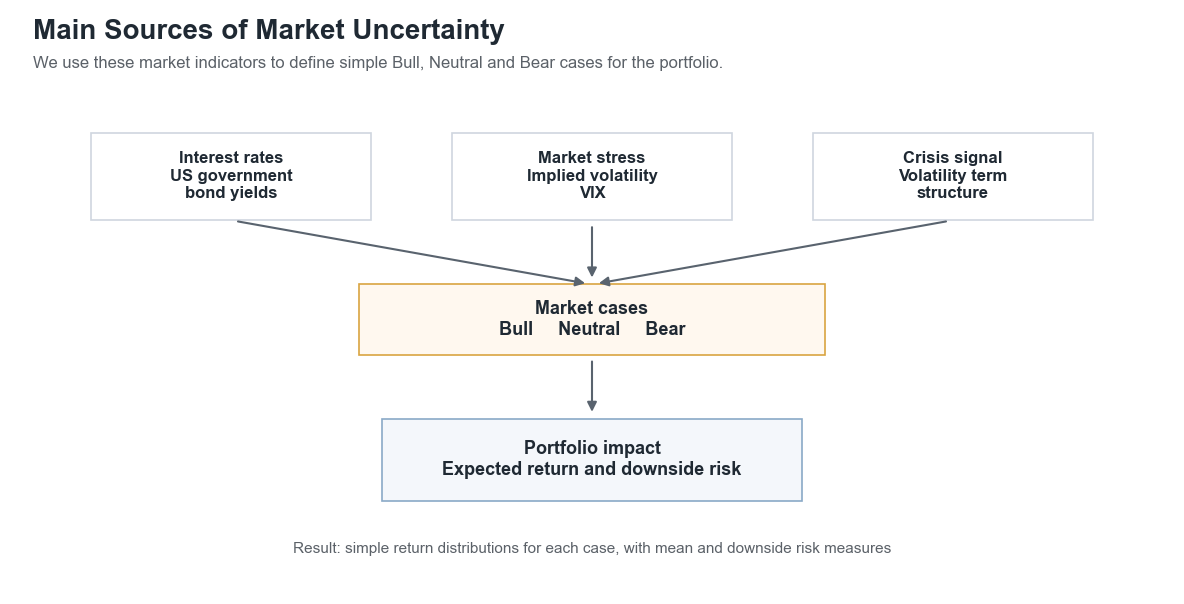

In [122]:
def draw_market_case_diagram():
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    def box(x, y, w, h, text, facecolor, edgecolor="#d5d8dc", fontsize=12, weight="normal"):
        patch = plt.Rectangle((x, y), w, h, facecolor=facecolor, edgecolor=edgecolor, linewidth=1.2)
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, fontweight=weight, color="#1f2933")
        return patch

    ax.text(0.02, 0.95, "Main Sources of Market Uncertainty", fontsize=20, fontweight="bold", ha="left", color="#1f2933")
    ax.text(0.02, 0.90, "We use these market indicators to define simple Bull, Neutral and Bear cases for the portfolio.", fontsize=12, ha="left", color="#5b6168")

    drivers = [
        (0.07, 0.64, "Interest rates", "US government\nbond yields"),
        (0.38, 0.64, "Market stress", "Implied volatility\nVIX"),
        (0.69, 0.64, "Crisis signal", "Volatility term\nstructure"),
    ]
    for x, y, title, subtitle in drivers:
        box(x, y, 0.24, 0.15, f"{title}\n{subtitle}", "#ffffff", edgecolor="#cfd6df", fontsize=12, weight="bold")

    box(0.30, 0.41, 0.40, 0.12, "Market cases\nBull     Neutral     Bear", "#fff8ef", edgecolor="#d9a441", fontsize=13, weight="bold")
    box(0.32, 0.16, 0.36, 0.14, "Portfolio impact\nExpected return and downside risk", "#f4f7fb", edgecolor="#8aa9c7", fontsize=13, weight="bold")

    arrowprops = dict(arrowstyle="-|>", color="#59636e", linewidth=1.5, shrinkA=5, shrinkB=5, mutation_scale=14)
    for x, _, _, _ in drivers:
        ax.annotate("", xy=(0.50, 0.53), xytext=(x + 0.12, 0.64), arrowprops=arrowprops)
    ax.annotate("", xy=(0.50, 0.30), xytext=(0.50, 0.41), arrowprops=arrowprops)

    ax.text(0.50, 0.07, "Result: simple return distributions for each case, with mean and downside risk measures", ha="center", fontsize=11, color="#5b6168")
    plt.tight_layout()
    plt.show()


draw_market_case_diagram()

## 6. Strategic Portfolio: 20-Fold Stacked Mean-CVaR

In [123]:
def stacked_mean_cvar_portfolio(R, num_bootstraps, sample_size_days, num_frontier_portfolios, frontier_index, stacking_folds):
    T, I = R.shape
    sample_size = min(sample_size_days, T)
    G, h, A, b = exposure_constraints(I, max_exposure=max_exposure)
    sample_portfolios = np.full((I, num_bootstraps), np.nan)

    for bootstrap in range(num_bootstraps):
        sample_index = np.random.choice(T, size=sample_size, replace=True)
        R_sample = R.iloc[sample_index].values
        opt = ft.MeanCVaR(R_sample, G=G, h=h, A=A, b=b, alpha=alpha)
        frontier = opt.efficient_frontier(num_frontier_portfolios)
        sample_portfolios[:, bootstrap] = frontier[:, frontier_index]

    exposure = ft.exposure_stacking(stacking_folds, sample_portfolios)
    return pd.Series(exposure, index=R.columns, name="Strategic exposure"), pd.DataFrame(sample_portfolios, index=R.columns)


strategic_exposure, bootstrap_exposures = stacked_mean_cvar_portfolio(
    asset_pnl,
    num_bootstraps=num_bootstraps,
    sample_size_days=sample_size_days,
    num_frontier_portfolios=num_frontier_portfolios,
    frontier_index=frontier_index,
    stacking_folds=stacking_folds,
)

exposure_display = pd.DataFrame({"Strategic exposure": strategic_exposure})
np.round(100 * exposure_display, 2)

,Strategic exposure
Ticker,
Emerging markets ex China,17.7000
Poland / Eastern Europe proxy,5.0200
Spain,17.5200
Gold,19.6700
Latin America,3.5500
Nasdaq 100,16.5500
US broad equity,20.0000


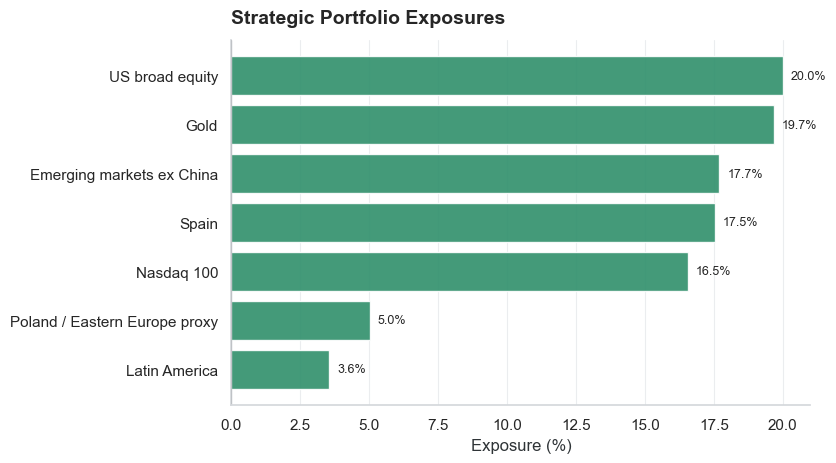

In [124]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_exposure = strategic_exposure.sort_values()
colors = ["#2f8f6b" if value >= 0 else "#b4433c" for value in plot_exposure]
ax.barh(plot_exposure.index, 100 * plot_exposure.values, color=colors, alpha=0.9)
ax.set_title("Strategic Portfolio Exposures", loc="left", fontsize=14, pad=12)
ax.set_xlabel("Exposure (%)")
ax.axvline(0, color="#2f3437", linewidth=0.8)
for i, value in enumerate(plot_exposure.values):
    ax.text(100 * value + 0.3, i, f"{100 * value:.1f}%", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.8)
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.show()

strategic_pnl = asset_pnl @ strategic_exposure
strategic_pnl.name = "Strategic portfolio log return"

## 7. Vorobets-Style EP/FFR Helpers

This mirrors the chapter pattern: define historical states, compute state-specific mean and volatility views, solve EP state probability vectors, then resample historical observations state-dependently.

In [125]:
def quantile_state_masks(x, low_q=0.25, high_q=0.75):
    low = x <= np.quantile(x, low_q)
    high = x > np.quantile(x, high_q)
    mid = ~(low | high)
    return {
        "Low": low,
        "Mid": mid,
        "High": high,
    }


def binary_state_masks(x, threshold=0.0, normal_label="Normal", crisis_label="Crisis"):
    return {
        normal_label: x <= threshold,
        crisis_label: x > threshold,
    }


def ep_state_probabilities(state_variable, masks, half_life_fraction=0.5):
    x = np.asarray(state_variable).reshape(-1)
    T_tilde = len(x)
    p_exp = ft.exp_decay_probs(x[:, np.newaxis], half_life=max(1, int(T_tilde * half_life_fraction)))

    A = np.vstack((np.ones((1, T_tilde)), x[np.newaxis]))
    G = x[np.newaxis] ** 2

    state_prob = []
    state_labels = []
    states_vector = np.full(T_tilde, -1, dtype=int)

    for state_index, (label, mask) in enumerate(masks.items()):
        if np.sum(mask) < 5:
            raise ValueError(f"State '{label}' has too few observations: {np.sum(mask)}")
        mu = np.mean(x[mask])
        sigma = np.std(x[mask])
        b = np.array([[1.0], [mu]])
        h = np.array([[sigma**2 + mu**2]])
        q = ft.entropy_pooling(p_exp, A, b, G, h)
        state_prob.append((q / np.sum(q))[:, 0])
        state_labels.append(label)
        states_vector[mask] = state_index

    if np.any(states_vector < 0):
        raise ValueError("Some observations were not assigned to a state.")

    return np.vstack(state_prob).T, states_vector, state_labels


def resampling_indices(num_paths, horizon, initial_state, state_prob, states_vector):
    sim = np.full((num_paths, horizon), -1, dtype=int)
    historical_indices = np.arange(len(states_vector))
    for path in range(num_paths):
        current_state = initial_state
        for step in range(horizon):
            idx = np.random.choice(historical_indices, p=state_prob[:, current_state])
            sim[path, step] = idx
            current_state = states_vector[idx]
    return sim


def terminal_returns_by_state(portfolio_log_returns, state_variable, masks, horizon, num_paths):
    aligned = pd.concat([portfolio_log_returns, state_variable.rename("state")], axis=1).dropna()
    pf = aligned.iloc[:, 0].values
    x = aligned["state"].values
    local_masks = {label: np.asarray(mask.loc[aligned.index] if isinstance(mask, pd.Series) else mask[-len(aligned):]) for label, mask in masks.items()}
    state_prob, states_vector, state_labels = ep_state_probabilities(x, local_masks, state_half_life_fraction)

    terminal = {}
    for initial_state, label in enumerate(state_labels):
        sim_idx = resampling_indices(num_paths, horizon, initial_state, state_prob, states_vector)
        terminal[label] = cumulative_log_to_simple_return(pf[sim_idx])
    return terminal, state_prob, states_vector, state_labels


def ep_joint_state_probabilities(state_variables, masks, half_life_fraction=0.5):
    X = np.asarray(state_variables)
    T_tilde, num_vars = X.shape
    p_exp = ft.exp_decay_probs(X, half_life=max(1, int(T_tilde * half_life_fraction)))

    A = np.vstack((np.ones((1, T_tilde)), X.T))
    G = (X.T) ** 2

    state_prob = []
    state_labels = []
    states_vector = np.full(T_tilde, -1, dtype=int)

    for state_index, (label, mask) in enumerate(masks.items()):
        mask = np.asarray(mask)
        if np.sum(mask) < 5:
            raise ValueError(f"Joint state '{label}' has too few observations: {np.sum(mask)}")
        mu = np.mean(X[mask, :], axis=0)
        sigma = np.std(X[mask, :], axis=0)
        b = np.vstack(([[1.0]], mu[:, np.newaxis]))
        h = (sigma**2 + mu**2)[:, np.newaxis]
        q = ft.entropy_pooling(p_exp, A, b, G, h)
        state_prob.append((q / np.sum(q))[:, 0])
        state_labels.append(label)
        states_vector[mask] = state_index

    if np.any(states_vector < 0):
        raise ValueError("Some observations were not assigned to a joint state.")

    return np.vstack(state_prob).T, states_vector, state_labels


def terminal_returns_by_joint_state(portfolio_log_returns, state_df, masks, horizon, num_paths, labels_to_plot=None):
    aligned = pd.concat([portfolio_log_returns, state_df], axis=1).dropna()
    pf = aligned.iloc[:, 0].values
    X = aligned.iloc[:, 1:].values
    local_masks = {label: np.asarray(mask.loc[aligned.index]) for label, mask in masks.items()}

    state_prob, states_vector, state_labels = ep_joint_state_probabilities(X, local_masks, state_half_life_fraction)
    labels_to_plot = state_labels if labels_to_plot is None else labels_to_plot

    terminal = {}
    for initial_state, label in enumerate(state_labels):
        sim_idx = resampling_indices(num_paths, horizon, initial_state, state_prob, states_vector)
        if label in labels_to_plot:
            terminal[label] = cumulative_log_to_simple_return(pf[sim_idx])
    return terminal, state_prob, states_vector, state_labels


def plot_terminal_kde(terminal, title):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for label, values in terminal.items():
        color = palette.get(label, None)
        sns.kdeplot(100 * values, label=label, ax=ax, linewidth=2.2, color=color, fill=False)
        mean_value = 100 * np.mean(values)
        ax.axvline(mean_value, color=color, linewidth=1.0, linestyle=":", alpha=0.8)
    ax.axvline(0, color="#2f3437", linewidth=0.9, linestyle="--", alpha=0.8)
    ax.set_title(title, loc="left", fontsize=14, pad=12)
    ax.set_xlabel("Terminal simple return (%)")
    ax.set_ylabel("Density")
    ax.legend(frameon=False, title="State")
    ax.grid(axis="y", alpha=0.8)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def ep_diagnostics_table(state_prob, state_labels, states_vector):
    T_tilde = state_prob.shape[0]
    p = np.ones((T_tilde, 1)) / T_tilde
    rows = []
    for state_index, label in enumerate(state_labels):
        q = state_prob[:, state_index][:, np.newaxis]
        positive = q[:, 0] > 0
        re = np.sum(q[positive, 0] * (np.log(q[positive, 0]) - np.log(p[positive, 0])))
        ens = float(np.exp(-re) * T_tilde)
        rows.append({
            "State": label,
            "Observations": int(np.sum(states_vector == state_index)),
            "Relative entropy": re,
            "Effective scenarios": ens,
            "Effective scenarios %": ens / T_tilde,
        })
    return pd.DataFrame(rows).set_index("State")


def terminal_summary_table(terminal, alpha=0.90):
    rows = []
    for label, values in terminal.items():
        losses = -np.asarray(values)
        var = np.quantile(losses, alpha)
        cvar = losses[losses >= var].mean()
        rows.append({
            "State": label,
            "Mean return %": 100 * np.mean(values),
            "Volatility %": 100 * np.std(values),
            "VaR loss %": 100 * var,
            "CVaR loss %": 100 * cvar,
        })
    return pd.DataFrame(rows).set_index("State")


def display_ffr_diagnostics(title, terminal, state_prob, state_labels, states_vector):
    print(title)
    print("EP diagnostics")
    display(np.round(ep_diagnostics_table(state_prob, state_labels, states_vector), 4))
    print("Terminal simple-return diagnostics")
    display(np.round(terminal_summary_table(terminal, alpha=alpha), 4))

## 8. Separate FFR Test: VIX Low / Mid / High

VIX states, H=21
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
Low,554,1.3041,601.4401,0.2714
Mid,1108,0.6102,"1,203.7964",0.5432
High,554,0.9433,862.7484,0.3893


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
Low,2.7830,3.2095,1.1406,3.1630
Mid,2.1205,3.9626,2.7632,5.2800
High,0.9872,5.0970,5.5226,8.7166


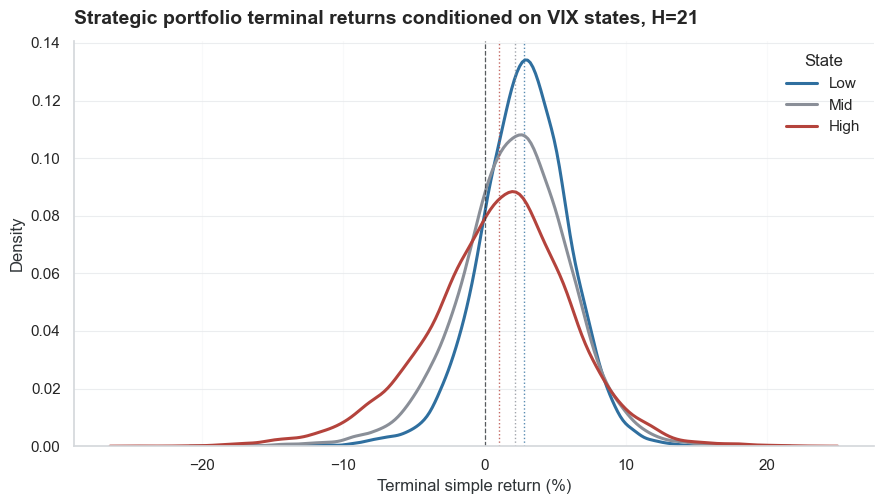

VIX states, H=126
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
Low,554,1.3041,601.4401,0.2714
Mid,1108,0.6102,"1,203.7964",0.5432
High,554,0.9433,862.7484,0.3893


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
Low,15.6863,10.4725,-2.4599,2.9501
Mid,14.7931,10.6473,-1.2526,4.0800
High,13.3749,11.0645,0.5937,6.1632


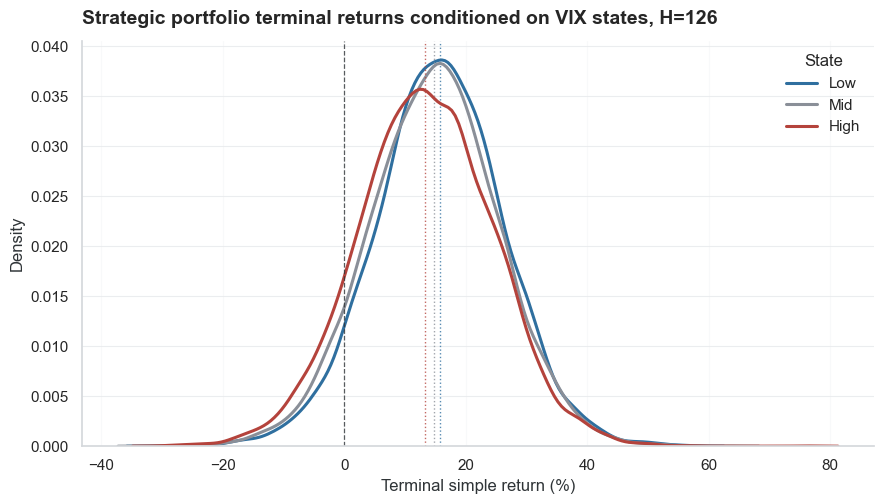

In [126]:
vix = state_raw["VIX"].reindex(strategic_pnl.index).ffill().dropna()
vix_masks = {label: pd.Series(mask, index=vix.index) for label, mask in quantile_state_masks(vix.values).items()}

for horizon in ffr_horizons:
    terminal_vix, state_prob_vix, states_vector_vix, labels_vix = terminal_returns_by_state(
        strategic_pnl, vix, vix_masks, horizon=horizon, num_paths=ffr_num_paths
    )
    display_ffr_diagnostics(f"VIX states, H={horizon}", terminal_vix, state_prob_vix, labels_vix, states_vector_vix)
    plot_terminal_kde(terminal_vix, f"Strategic portfolio terminal returns conditioned on VIX states, H={horizon}")

## 9. Separate FFR Test: VIX Term Structure Normal / Crisis

Crisis is currently defined as `VIX - VIX3M > 0`. This threshold is a free parameter.

VIX term states, H=21
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
Normal,2032,0.1229,"1,959.6454",0.8843
Crisis,184,1.7634,379.9495,0.1715


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
Normal,1.6610,4.9316,4.4035,7.4841
Crisis,0.4082,6.2409,7.2171,10.9515


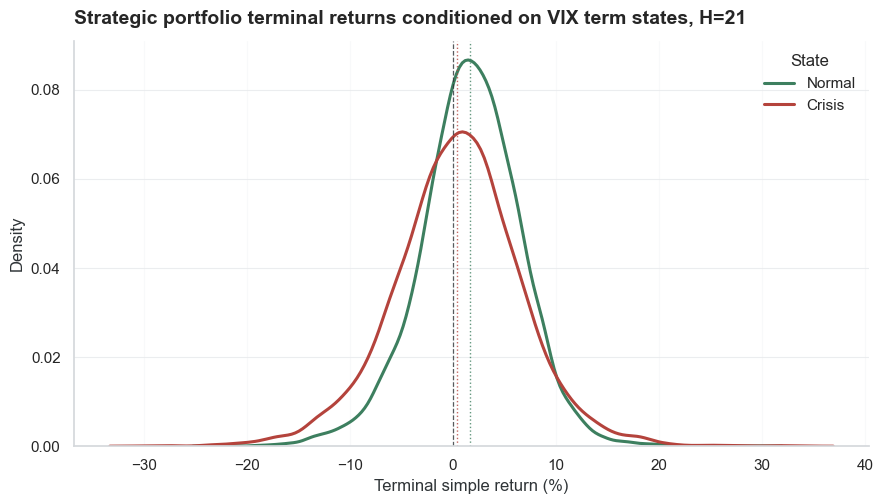

VIX term states, H=126
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
Normal,2032,0.1229,"1,959.6454",0.8843
Crisis,184,1.7634,379.9495,0.1715


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
Normal,10.4133,13.3641,6.2988,12.4903
Crisis,8.9297,13.9412,8.1496,14.3103


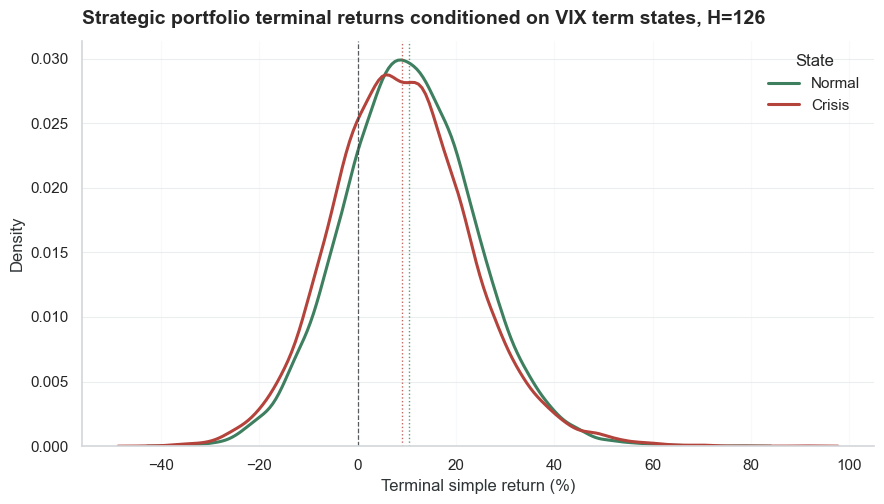

In [127]:
vix_term_threshold = 0.0
vix_term = state_raw["VIX term"].reindex(strategic_pnl.index).ffill().dropna()
term_masks = {
    label: pd.Series(mask, index=vix_term.index)
    for label, mask in binary_state_masks(vix_term.values, threshold=vix_term_threshold).items()
}

for horizon in ffr_horizons:
    terminal_term, state_prob_term, states_vector_term, labels_term = terminal_returns_by_state(
        strategic_pnl, vix_term, term_masks, horizon=horizon, num_paths=ffr_num_paths
    )
    display_ffr_diagnostics(f"VIX term states, H={horizon}", terminal_term, state_prob_term, labels_term, states_vector_term)
    plot_terminal_kde(terminal_term, f"Strategic portfolio terminal returns conditioned on VIX term states, H={horizon}")

## 10. Separate FFR Test: US 30Y Zero-Coupon Return States

For yields we avoid raw level buckets as the primary engine. The FFR state variable is the stationary transformation of a 30Y zero-coupon proxy, partitioned at the 15th and 85th percentiles. Low means adverse 30Y ZCB return / rising-yield pressure; High means supportive 30Y ZCB return / falling-yield pressure.

30Y ZCB states, H=21
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
30Y ZCB down / rising-yield pressure,366,1.4533,518.0962,0.2338
30Y neutral,1548,0.3357,"1,584.0635",0.7148
30Y ZCB up / falling-yield support,302,1.5557,467.6801,0.2110


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
30Y ZCB down / rising-yield pressure,1.1000,4.7199,4.7990,7.0759
30Y neutral,2.1607,4.5697,3.4527,5.7398
30Y ZCB up / falling-yield support,1.3348,4.8075,4.7307,7.2804


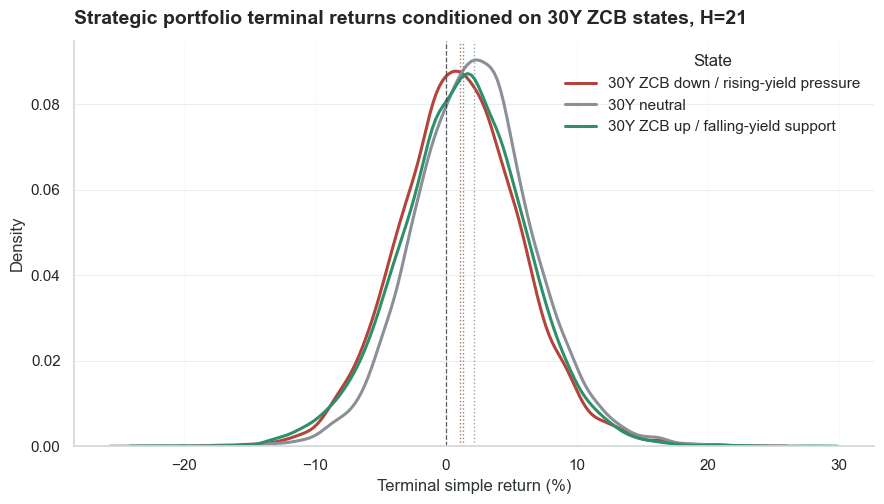

30Y ZCB states, H=126
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
30Y ZCB down / rising-yield pressure,366,1.4533,518.0962,0.2338
30Y neutral,1548,0.3357,"1,584.0635",0.7148
30Y ZCB up / falling-yield support,302,1.5557,467.6801,0.2110


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
30Y ZCB down / rising-yield pressure,11.2251,12.4927,4.3205,9.5417
30Y neutral,12.4417,12.5624,3.1975,8.1096
30Y ZCB up / falling-yield support,11.2314,12.4474,4.0353,9.2753


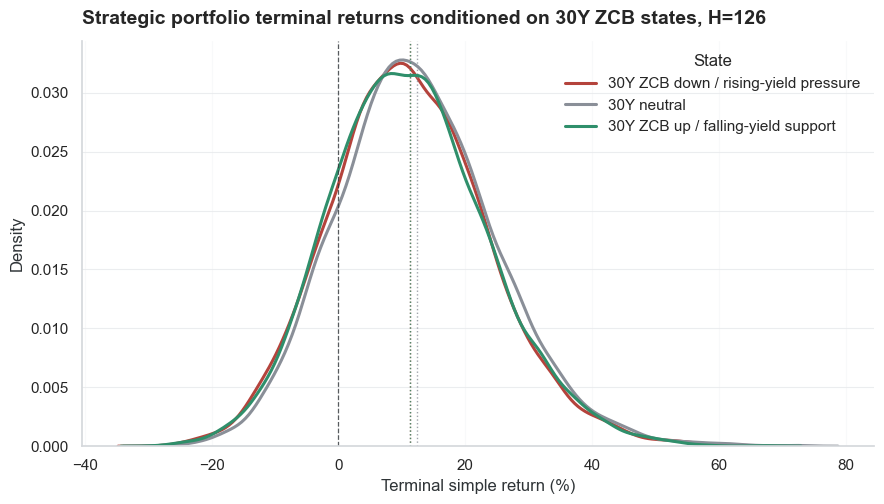

In [128]:
zcb_30y_chg = state_raw["US 30Y ZCB log change"].reindex(strategic_pnl.index).ffill().dropna()
zcb_masks_raw = quantile_state_masks(zcb_30y_chg.values, low_q=0.15, high_q=0.85)
zcb_masks = {
    "30Y ZCB down / rising-yield pressure": pd.Series(zcb_masks_raw["Low"], index=zcb_30y_chg.index),
    "30Y neutral": pd.Series(zcb_masks_raw["Mid"], index=zcb_30y_chg.index),
    "30Y ZCB up / falling-yield support": pd.Series(zcb_masks_raw["High"], index=zcb_30y_chg.index),
}

for horizon in ffr_horizons:
    terminal_zcb, state_prob_zcb, states_vector_zcb, labels_zcb = terminal_returns_by_state(
        strategic_pnl, zcb_30y_chg, zcb_masks, horizon=horizon, num_paths=ffr_num_paths
    )
    display_ffr_diagnostics(f"30Y ZCB states, H={horizon}", terminal_zcb, state_prob_zcb, labels_zcb, states_vector_zcb)
    plot_terminal_kde(terminal_zcb, f"Strategic portfolio terminal returns conditioned on 30Y ZCB states, H={horizon}")

## 11. Joint Bull / Neutral / Bear FFR Cases

- Bull: VIX low, VIX term normal, 30Y ZCB supportive.
- Neutral: VIX mid, VIX term normal, 30Y neutral.
- Bear: VIX high, VIX term crisis, 30Y ZCB adverse.

An `Other` bucket is included internally so every historical observation has a transition state, but it is not plotted.

In [129]:
joint_state_df = pd.concat(
    [
        vix.rename("VIX"),
        vix_term.rename("VIX term"),
        zcb_30y_chg.rename("30Y ZCB log change"),
    ],
    axis=1,
).dropna()

vix_low = vix_masks["Low"].reindex(joint_state_df.index).fillna(False)
vix_mid = vix_masks["Mid"].reindex(joint_state_df.index).fillna(False)
vix_high = vix_masks["High"].reindex(joint_state_df.index).fillna(False)
term_normal = term_masks["Normal"].reindex(joint_state_df.index).fillna(False)
term_crisis = term_masks["Crisis"].reindex(joint_state_df.index).fillna(False)
zcb_down = zcb_masks["30Y ZCB down / rising-yield pressure"].reindex(joint_state_df.index).fillna(False)
zcb_neutral = zcb_masks["30Y neutral"].reindex(joint_state_df.index).fillna(False)
zcb_up = zcb_masks["30Y ZCB up / falling-yield support"].reindex(joint_state_df.index).fillna(False)

joint_masks_core = {
    "Bull": vix_low & term_normal & zcb_up,
    "Neutral": vix_mid & term_normal & zcb_neutral,
    "Bear": vix_high & term_crisis & zcb_down,
}
assigned = pd.concat(joint_masks_core.values(), axis=1).any(axis=1)
joint_masks = {
    **joint_masks_core,
    "Other": ~assigned,
}

pd.Series({label: int(mask.sum()) for label, mask in joint_masks.items()}, name="Observations")

Bull         63
Neutral     780
Bear         30
Other      1343
Name: Observations, dtype: int64

Joint Bull / Neutral / Bear states, H=21
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
Bull,63,3.1438,95.5524,0.0431
Neutral,780,0.8453,951.5690,0.4294
Bear,30,3.1611,93.9138,0.0424
Other,1343,0.0844,"2,036.6706",0.9191


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
Bull,3.9694,4.3019,1.3356,3.8931
Neutral,3.1486,4.1315,1.9951,4.2124
Bear,1.8858,6.0682,5.6171,9.0533


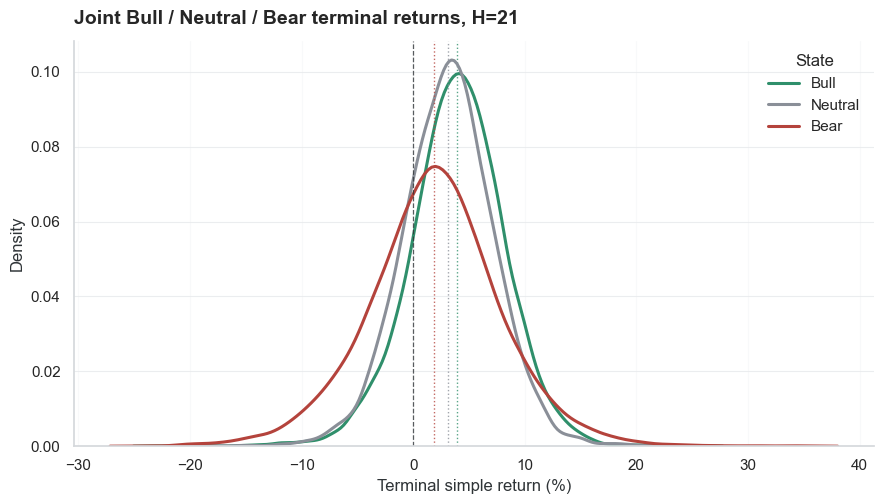

Joint Bull / Neutral / Bear states, H=126
EP diagnostics


,Observations,Relative entropy,Effective scenarios,Effective scenarios %
State,,,,
Bull,63,3.1438,95.5524,0.0431
Neutral,780,0.8453,951.5690,0.4294
Bear,30,3.1611,93.9138,0.0424
Other,1343,0.0844,"2,036.6706",0.9191


Terminal simple-return diagnostics


,Mean return %,Volatility %,VaR loss %,CVaR loss %
State,,,,
Bull,21.5477,12.3038,-6.1039,-0.5940
Neutral,20.4663,12.1690,-5.4707,-0.0062
Bear,18.8947,13.1764,-2.6889,3.0534


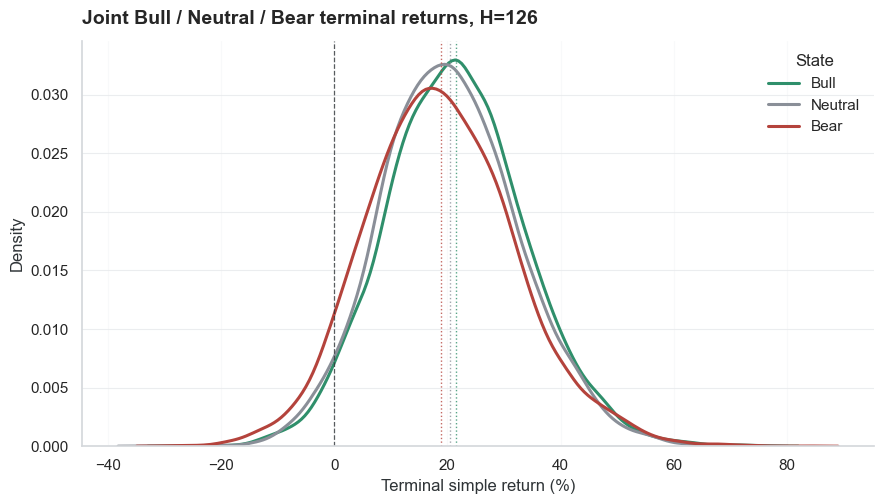

In [130]:
for horizon in [21, 126]:
    terminal_joint, state_prob_joint, states_vector_joint, labels_joint = terminal_returns_by_joint_state(
        strategic_pnl,
        joint_state_df,
        joint_masks,
        horizon=horizon,
        num_paths=ffr_num_paths,
        labels_to_plot=["Bull", "Neutral", "Bear"],
    )
    display_ffr_diagnostics(f"Joint Bull / Neutral / Bear states, H={horizon}", terminal_joint, state_prob_joint, labels_joint, states_vector_joint)
    plot_terminal_kde(terminal_joint, f"Joint Bull / Neutral / Bear terminal returns, H={horizon}")